**<center> ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ ОБРАЗОВАТЕЛЬНОЕ УЧРЕЖДЕНИЕ</center>**
**<center>ГОРОДА МОСКВЫ</center>**
**<center>ДОПОЛНИТЕЛЬНОГО ПРОФЕССИОНАЛЬНОГО ОБРАЗОВАНИЯ</center>**
**<center>ЦЕНТР ПРОФЕССИОНАЛЬНЫХ КВАЛИФИКАЦИЙ И СОДЕЙСТВИЯ ТРУДОУСТРОЙСТВУ</center>**
**<center>«ПРОФЕССИОНАЛ»</center>**
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

<center> ИТОГОВАЯ АТТЕСТАЦИОННАЯ РАБОТА </center>
<center> на тему </center>
<center> «Анализ данных с использованием Python» </center>
<center> (на примере анализа данных исследуемого продукта) </center>
<center>слушателя Александровской Натальи Алексеевны<br>группы № 164 </center>
 <center>по программе профессиональной переподготовки </center>
<center> «Python для анализа данных» </center>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

<center> Москва, 2024

### Цель исследования:


Цель данного проекта — выявить, какие признаки имеют наибольшее влияние на рейтинг вина, составляемого специализированным журналом Wine Enthusiast. Для анализа используется набор данных из Kaggle (профессиональное сообщество специалистов по обработке данных и машинному обучению). Датафрейм состоит из 13 признаков (2 числовых признака и 11 категориальных признаков).

Анализ данных предполагает последовательное выполнение следующих этапов исследования:<br>
<a href=#1>1.  Предобработка данных</a><br>
<a href=#2>2.  Исследовательский анализ данных</a><br>
<a href=#3>3.  Составление структуры развития рынка вина каждого региона</a><br>
<a href=#4>4.  Проведение исследования статистических показателей зависимости цены вина от рейтинга в регионе</a><br>
<a href=#5>5.  Проверка гипотез</a><br>
<a href=#6>6.  Выводы</a><br>


### Столбцы данных
- Страна - страна происхождения вина.<br>
- Описание — описание вкусового профиля вина.<br>
- Обозначение - виноградник-поставщик винограда для изготовления вина.<br>
- Рейтинг - оценка вина специализированным журналом Wine Enthusiast, выраженная в баллах по шкале от 1 до 100.<br>
- Цена - цена одной бутылки вина.<br>
- Провинция — регион (провинция, штат) производства вина.<br>
- Регион 1 — зона виноделия в регионе (например, долина Напа в Калифорнии). <br>
- Регион 2 — (необязательно) терруар виноделия - более конкретная область в винодельческом регионе (например, Резерфорд в долине Напа).<br>
- Разновидность — сорт винограда, используемый в производстве вина (например, Пино Нуар).<br>
- Винодельня — производитель вина.<br>

#  <a name="1">1.Предобработка данных</a>

### Импорт необходимых библиотек

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
sns.set_style("darkgrid")
plt.style.use('ggplot')
%matplotlib inline
import scipy.stats as st
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.linear_model import LinearRegression
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### Загрузка данных

In [5]:
df = pd.read_csv('wine_reviews.csv')
df.head()

,country,description,designation,points,price,province,region_1,region_2,variety,winery
0,US,"With a delicate, silky mouthfeel and bright ac...",NaN,86,23.0,California,Central Coast,Central Coast,Pinot Noir,MacMurray Ranch
1,Italy,D'Alceo is a drop dead gorgeous wine that ooze...,D'Alceo,96,275.0,Tuscany,Toscana,NaN,Red Blend,Castello dei Rampolla
2,France,The great dominance of Cabernet Sauvignon in t...,NaN,91,40.0,Bordeaux,Haut-Médoc,NaN,Bordeaux-style Red Blend,Château Bernadotte
3,Italy,"The modest cherry, dark berry and black tea no...",NaN,81,15.0,Tuscany,Chianti Classico,NaN,Sangiovese,Valiano
4,US,"Exceedingly light in color, scent and flavor, ...",NaN,83,25.0,Oregon,Rogue Valley,Southern Oregon,Pinot Noir,Deer Creek


* Столбцы названы корректно, замена не нужна.

### Удаление дубликатов

In [6]:
print(df.shape)
print(df.duplicated().sum())

(20000, 10)
1119


In [7]:
df = df.drop_duplicates().reset_index(drop=True) 

In [8]:
print(df.shape)
print(df.duplicated().sum())

(18881, 10)
0


### Проверка типов данных

In [9]:
df.dtypes

country         object
description     object
designation     object
points           int64
price          float64
province        object
region_1        object
region_2        object
variety         object
winery          object
dtype: object

* Типы данных в столбцах соответствуют содержимому, заменять не нужно.

### Обработка пропусков

In [10]:
MissingValue = df.isnull().sum().sort_values(ascending = False)
Percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False)
MissingData = pd.concat([MissingValue, Percent], axis=1, keys=['Пропущенные значения', 'Процент'])
MissingData

,Пропущенные значения,Процент
region_2,11278,59.732006
designation,5673,30.046078
region_1,3260,17.266035
price,1688,8.940204
country,0,0.000000
description,0,0.000000
points,0,0.000000
province,0,0.000000
variety,0,0.000000
winery,0,0.000000


* Пропуски в столбцах designation, price, region_1, region_2.

In [11]:
countries = df.groupby(by='country').count()[['province','region_1', 'region_2', 'designation']].sort_values(by='province', ascending=False)
countries.head(15)

,province,region_1,region_2,designation
country,,,,
US,7786,7769,7603,5003
Italy,2912,2912,0,2067
France,2601,2599,0,1834
Spain,1035,1035,0,810
Chile,744,0,0,622
Portugal,706,0,0,644
Argentina,685,685,0,495
Australia,597,597,0,417
New Zealand,412,0,0,205


* Данные по региону 1 есть всего для 7 стран, их можно учитывать для анализа данных по этим странам. Удалять или заменять нецелесообразно.
* Данные по региону 2 есть только для США, столбец можно сохранить для анализа данных по этой стране.
* Данные по происхождению designation отсутствуют равномерно для всех стран.

In [12]:
countries = df.groupby(df['designation']).count()['province'].sort_values(ascending=False)
countries.head(10)

designation
Reserve           322
Reserva           228
Estate            211
Barrel sample     157
Riserva            92
Barrel Sample      76
Brut               68
Estate Grown       61
Estate Bottled     51
Old Vine           48
Name: province, dtype: int64

* Riserva, Reserva или Reserve наиболее часто встречается на бутылках. Это один тот же термин, но в разных странах, у разных производителей может означать разное. Использование не регламентировано. В столбце много дублей, но объединять их не имеет смысла, потому что работа большая (322 разничных наименования), а польза от информации не очевидна, пока оставим как есть.

In [13]:
df.describe()

,points,price
count,18881.000000,17193.000000
mean,87.904666,33.325016
std,3.242825,40.301045
min,80.000000,5.000000
25%,86.000000,16.000000
50%,88.000000,24.000000
75%,90.000000,40.000000
max,100.000000,2300.000000


* Вина оценены в пунктах от 80 до 100 баллов. Средняя оценка 88.
* Цены вин от 5 до 2300. Средняя цена 33 сильно сдвинута вправо относительно медианы 24, что говорит о наличии в наборе премиальных вин.
* Поскольку в данных есть премиальные вина, то замена пропусков на среднее даст некорректный результат. Нужно либо удалять эти строки, либо искать способ адекватной замены значений. Будет зависить от задачи анализа. Пока оставим как есть.

### Добавление информации (столбцов)

In [14]:
df.describe(include=['O'])

,country,description,designation,province,region_1,region_2,variety,winery
count,18881,18881,13208,18881,15621,7603,18881,18881
unique,38,18880,8879,314,877,18,420,7454
top,US,"Ripe plum, game, truffle, leather and menthol ...",Reserve,California,Napa Valley,Central Coast,Pinot Noir,Williams Selyem
freq,7786,2,322,5576,756,1634,1839,51


* В наборе данные 38 стран 7454 виноделен. Больше всего представлено вин из США - 41% всех наименований.

In [15]:
from IPython.display import Image
Image(url='https://fortwine.ru/upload/medialibrary/787/7871f58b49b88d3fbc7e2e4efdd0ec70.jpg')

* По данным  OIV (Международная организация виноградарства и виноделия) на 2017 год доля США в объемах производства всего 9.3%, что соответствует только четвертому номеру в рейтинге. Топ-3 страны по производству вина европейские, их суммарная доля состявляет 44.5%.
* Имеет смысл смотреть на рынок так, как его видят сами игроки. Традиционно рынок делится на производителей Старого и Нового света. Под винами Старого Света понимаются главным образом вина из пяти стран, до середины XX века задававших тон в области виноделия: Франции, Италии, Германии, Испании и Португалии. Понятие Нового Света не совпадает с традиционным, ибо подразумевает все страны без сложившихся столетиями традиций и технологий виноградного виноделия. Обычно сюда относят вина из Аргентины, Чили, Уругвая, Австралии, Новой Зеландии, ЮАР, США и Канады.
* Такой подход, позволит также ответить на вопрос о причинах разницы между долями в номенклатуре винной продукции и объемах производства.

In [16]:
age = {
"Italy": "old",
"France": "old",
"Spain": "old",
"Germany": "old",
"Portugal": "old",
"Argentina": "new",
"Chile": "new",
"Uruguay": "new",
"Australia": "new",
"New Zealand": "new",
"South Africa": "new",
"US": "new",
"Canada": "new",
}

In [89]:
df['age']=df['country'].map(age)
old_new = df[['country', 'points', 'price','province', 'variety', 'winery', 'age']]
old_new.head()

,country,points,price,province,variety,winery,age
0,US,86,23.0,California,Pinot Noir,MacMurray Ranch,new
1,Italy,96,275.0,Tuscany,Red Blend,Castello dei Rampolla,old
2,France,91,40.0,Bordeaux,Bordeaux-style Red Blend,Château Bernadotte,old
3,Italy,81,15.0,Tuscany,Sangiovese,Valiano,old
4,US,83,25.0,Oregon,Pinot Noir,Deer Creek,new


In [90]:
old_new.isnull().sum()

country        0
points         0
price       1688
province       0
variety        0
winery         0
age          749
dtype: int64

In [91]:
old_new =old_new.dropna(axis='index', how='any', subset=['age'])

In [92]:
old_new.isnull().sum()

country        0
points         0
price       1604
province       0
variety        0
winery         0
age            0
dtype: int64

* В таблицу добавлена категоризация Новый/Старый свет и удалены нерелевантные столбцы.

age
new    10541
old     7591
Name: count, dtype: int64


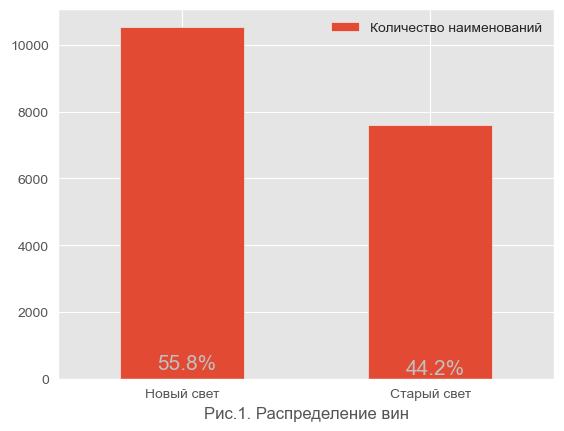

In [93]:
print(old_new['age'].value_counts())
old_new['age'].value_counts().plot(kind='bar')
plt.xlabel('Рис.1. Распределение вин')
plt.xticks([0, 1], ['Новый свет', 'Старый свет'], rotation=None)
plt.text(-0.1, 275, '55.8%', fontsize=15, color='silver')
plt.text(0.9, 150, '44.2%', fontsize=15, color='silver')
plt.legend(labels=[u'Количество наименований'], framealpha=0)

#  <a name="2"> 2. Исследовательский анализ данных</a>


### Производители

In [94]:
old_new.describe(include=['O'])

,country,province,variety,winery,age
count,18132,18132,18132,18132,18132
unique,13,180,365,7138,2
top,US,California,Pinot Noir,Williams Selyem,new
freq,7786,5576,1816,51,10541


* Остались данные по 13 странам, лидирующее положение у США.

In [95]:
old_new[old_new['variety'] == 'Pinot Noir']['winery'].nunique()

887

* Самым популярный сорт винограда Pinot Noir, есть в портфеле 887 производителей производителей.

In [96]:
portfolio = old_new['winery'].value_counts()
portfolio.head()

winery
Williams Selyem    51
DFJ Vinhos         36
Testarossa         35
Kendall-Jackson    33
Trapiche           30
Name: count, dtype: int64

In [97]:
portfolio.mean().round(2)

2.54

* В среднем винодельни производят 2-3 наименования.
* Самая крупная винодельня Williams Selyem производит 51 наименование (https://www.williamsselyem.com/wine/).

     province  winery  variety
age                           
new       111    3616      166
old        69    3543      282


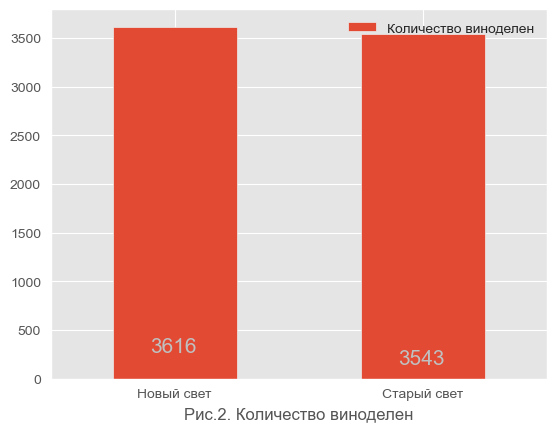

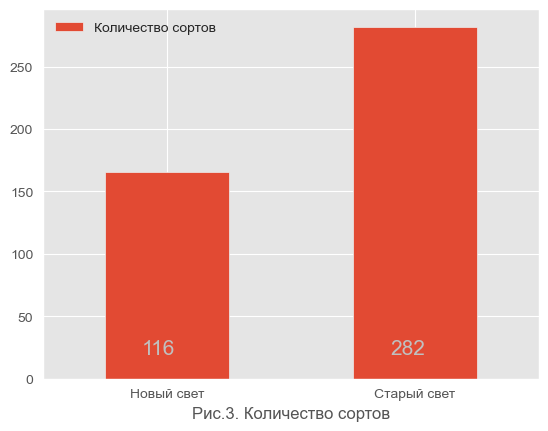

In [98]:
compar_1 = old_new.groupby('age')[['province','winery','variety']].nunique()
print(compar_1)
compar_2 = old_new.groupby('age')[['winery']].nunique().plot(kind='bar')
plt.xlabel('Рис.2. Количество виноделен')
plt.xticks([0, 1], ['Новый свет', 'Старый свет'], rotation=None)
plt.text(-0.1, 275, '3616', fontsize=15, color='silver')
plt.text(0.9, 150, '3543', fontsize=15, color='silver')
plt.legend(labels=[u'Количество виноделен'], framealpha=0)
compar_3 = old_new.groupby('age')[['variety']].nunique().plot(kind='bar')
plt.xlabel('Рис.3. Количество сортов')
plt.xticks([0, 1], ['Новый свет', 'Старый свет'], rotation=None)
plt.text(-0.1, 20, '116', fontsize=15, color='silver')
plt.text(0.9, 20, '282', fontsize=15, color='silver')
plt.legend(labels=[u'Количество сортов'], framealpha=0)

* Количество производителей сопоставимо, но в Новом свете меньше разнообразие сортов винограда.

In [99]:
old_world = old_new[old_new.age == 'old']
new_world = old_new[old_new.age == 'new']

   Новый свет  Старый свет
1         2.9          2.1


Text(0.5, 0, 'Рис.4. Среднее количество наименований в портфеле винодельни')

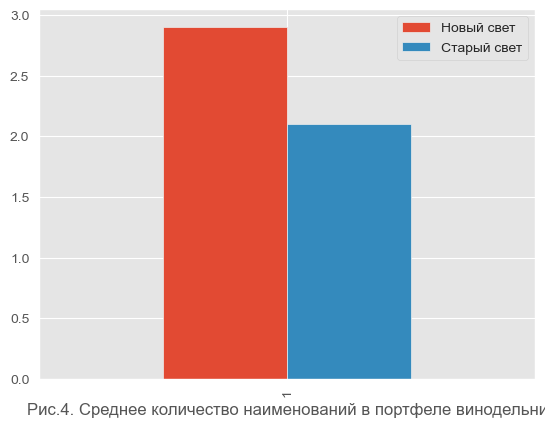

In [100]:
compar_2 = old_world['winery'].value_counts().mean().round(1)
compar_3 = new_world['winery'].value_counts().mean().round(1)

items = pd.DataFrame(
    {'Новый свет' : [compar_3],
     'Старый свет' : [compar_2]},
    index = [1])
print(items)

items.plot(kind='bar')
plt.xlabel('Рис.4. Среднее количество наименований в портфеле винодельни')

* Производители Нового света крупнее, производят в среднем больше наименований. В Старом свете - 2 наименования, в Новом - 3.

### Сорта винограда

In [101]:
old_variety_1 = old_world.groupby('variety')[['province','winery']].nunique().sort_values(by='winery', ascending=False)
old_variety_1.head()

,province,winery
variety,,
Red Blend,23,453
Bordeaux-style Red Blend,5,397
Sangiovese,4,246
Chardonnay,20,212
Rosé,27,200


In [111]:
old_variety_1 = old_world.groupby('variety')[['points', 'price']].median().sort_values(by='points', ascending=False)
old_variety_1.head().round(2)

,points,price
variety,,
Semillon-Sauvignon Blanc,95.0,NaN
Malbec-Tannat,92.5,24.0
Carricante,92.5,49.5
Nasco,92.0,65.0
Susumaniello,92.0,50.0


In [102]:
new_variety_1 = new_world.groupby('variety')[['province','winery']].nunique().sort_values(by='winery', ascending=False)
new_variety_1.head()

,province,winery
variety,,
Cabernet Sauvignon,44,949
Chardonnay,57,865
Pinot Noir,43,764
Sauvignon Blanc,60,461
Red Blend,36,445


In [112]:
new_variety_1 = new_world.groupby('variety')[['points', 'price']].median().sort_values(by='points', ascending=False)
new_variety_1.head().round(2)

,points,price
variety,,
Tokay,97.0,97.0
Scheurebe,95.0,50.0
Sauvignon Gris,94.0,40.0
Marsanne-Viognier,93.0,40.0
Tempranillo-Cabernet Sauvignon,93.0,55.0


* Портфели производителей Нового света однороднее. Сорта - лидеры по количеству виноделен их выпускающих отличаются в Старом и Новом свете. В Старом свете много локальных игроков, которые производят местные сорта.
* Лидеры по количеству производителей и по оценкам не совпадают как внутри региона так и между регионами.

### Оценки и цены

In [103]:
old_new.describe()

,points,price
count,18132.000000,16528.000000
mean,87.908063,33.480699
std,3.252587,39.688418
min,80.000000,5.000000
25%,86.000000,16.000000
50%,88.000000,24.000000
75%,90.000000,40.000000
max,100.000000,2300.000000


Text(0.5, 0, 'Рис.5. Распределение оценок вина')

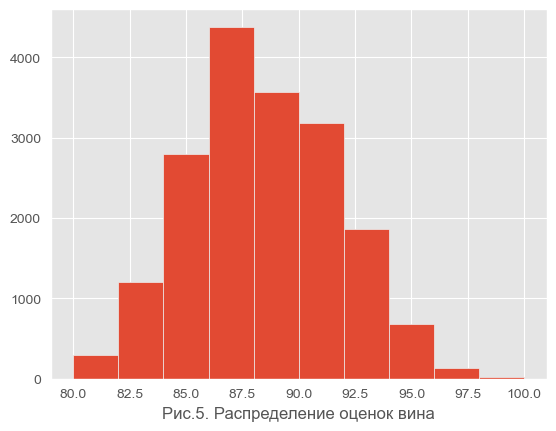

In [104]:
plt.hist(old_new['points'], bins=10)
plt.xlabel('Рис.5. Распределение оценок вина')

Средняя оценка вин 88. Распределение похоже на нормальное.

Text(0.5, 0, 'Рис.6. Распределение цен')

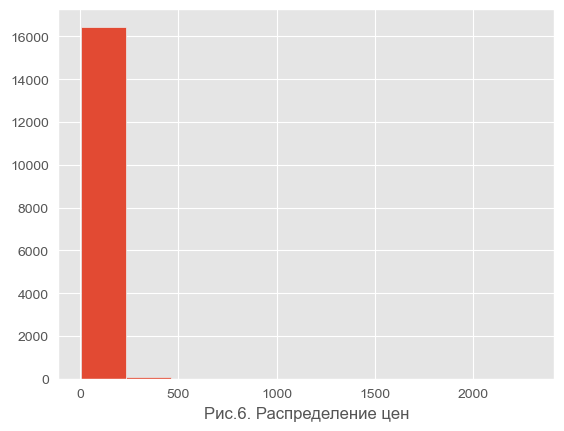

In [105]:
plt.hist(old_new['price'], bins=10)
plt.xlabel('Рис.6. Распределение цен')

С ценами две проблемы:

* присутствуют премиальные вина, которые искажают общую картину, их нужно смотреть отдельно. Для это позже сделаем отдельный датафрейм без нуля и сделаем иерархическую кластеризацию.

#  <a name="3">3. Составление структуры развития рынка вина регионов</a>

Text(0.5, 0, 'Рис.7. Доля различных сортов среди наименований вин Старого света')

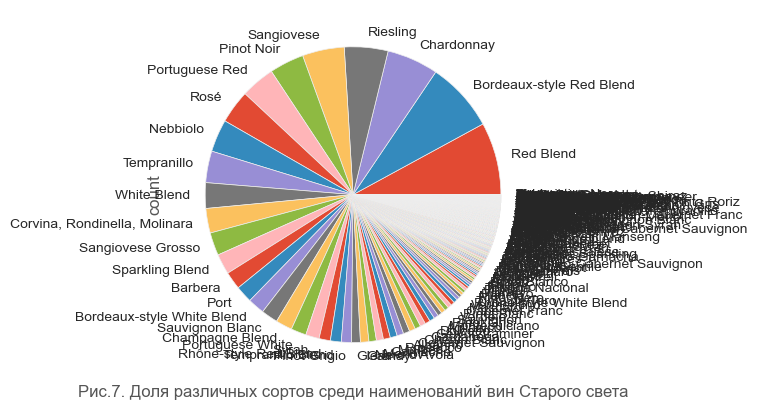

In [121]:
old_variety = old_world.variety.value_counts().plot(kind='pie')
plt.xlabel('Рис.7. Доля различных сортов среди наименований вин Старого света')

Text(0.5, 0, 'Рис.8. Доля различных сортов среди наименований вин Нового света.')

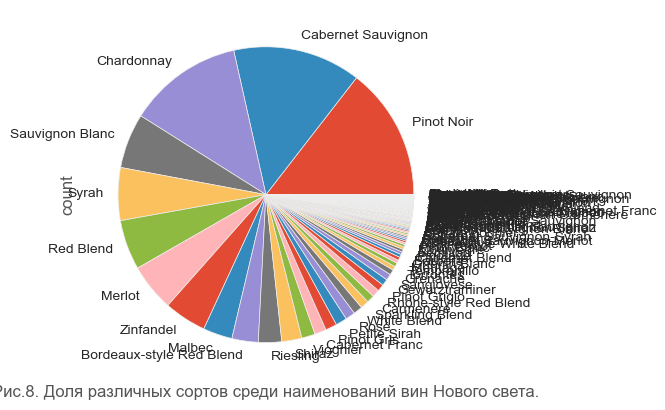

In [124]:
new_variety = new_world.variety.value_counts().plot(kind='pie')
plt.xlabel('Рис.8. Доля различных сортов среди наименований вин Нового света.')

* Топ наименований вин Нового и Старого света различается, но есть и пересечения. В Старом свете лидируют Red Blend, Chardonnay, Riesling. В Новом свете больше всего вин Pinot Noir, Cabernet Savignon и Chardonnay.

     points  price
age               
new    87.0   25.0
old    88.0   23.0


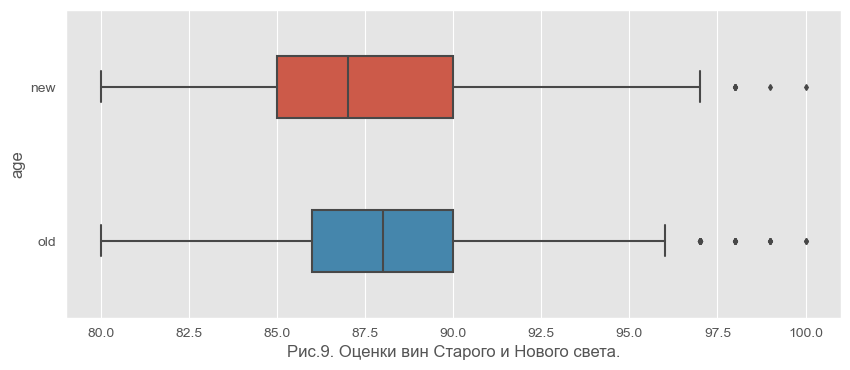

In [169]:
compar_2 = old_new.groupby('age')[['points','price']].median()
print(compar_2)
plt.figure(figsize = (10, 4))
sns.boxplot(data = old_new, x = 'points', y = 'age', width = 0.4, orient = 'h',  fliersize = 3)
plt.xlabel('Рис.9. Оценки вин Старого и Нового света.')
plt.show()

* В целом средняя оценка вин Старого света выше чем Нового, хотя цены Нового света выше.

Text(0.5, 0, 'Рис.10. Оценки наиболее представленных сортов.')

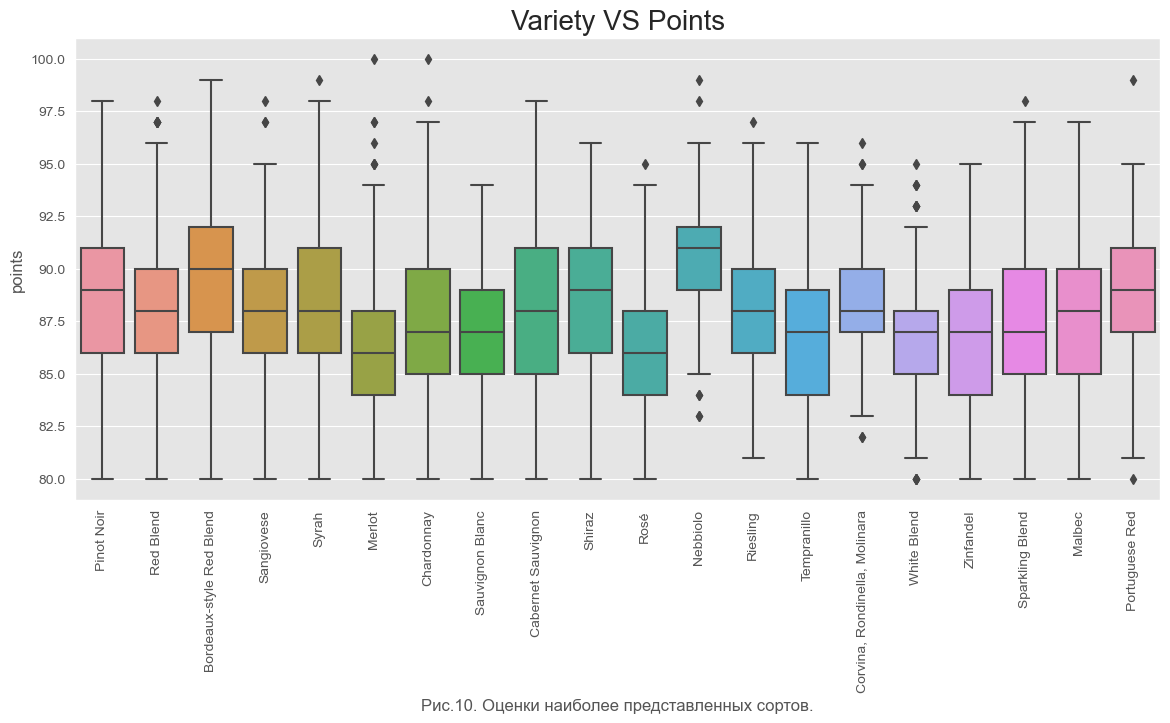

In [173]:
V1= old_new[old_new.variety.isin(old_new.variety.value_counts().head(20).index)]

plt.figure(figsize = (14,6))
plt.title("Variety VS Points", fontsize=20)
sns.boxplot(
    x = 'variety',
    y = 'points',
    data = V1
)
plt.xticks(rotation = 90)
plt.xlabel('Рис.10. Оценки наиболее представленных сортов.')

In [129]:
Riesling = old_new[old_new['variety'] == 'Riesling']
Riesling_comp = Riesling.groupby('age')[['points','price']].median()
Riesling_comp

,points,price
age,,
new,87.0,16.0
old,89.0,26.0


In [127]:
Chardonnay = old_new[old_new['variety'] == 'Chardonnay']
Chardonnay_comp = Chardonnay.groupby('age')[['points','price']].median()
Chardonnay_comp

,points,price
age,,
new,87.0,22.0
old,89.0,40.0


In [128]:
Chardonnay = old_new[old_new['variety'] == 'Red Blend']
Chardonnay_comp = Chardonnay.groupby('age')[['points','price']].median()
Chardonnay_comp

,points,price
age,,
new,88.0,28.0
old,88.0,28.0


In [172]:
Bordeaux = old_new[old_new['variety'] == 'Bordeaux-style Red Blend']
Bordeaux_comp = Bordeaux.groupby('age')[['points','price']].median()
Bordeaux_comp

,points,price
age,,
new,90.0,42.0
old,90.0,24.0


In [126]:
Cabernet_Sauvignon = old_new[old_new['variety'] == 'Cabernet Sauvignon']
Cabernet_Sauvignon_comp = Cabernet_Sauvignon.groupby('age')[['points','price']].median()
Cabernet_Sauvignon_comp

,points,price
age,,
new,88.0,33.0
old,88.0,30.0


In [131]:
Pinot_Noir = old_new[old_new['variety'] == 'Pinot Noir']
Pinot_Noir_comp = Pinot_Noir.groupby('age')[['points','price']].median()
Pinot_Noir_comp

,points,price
age,,
new,89.0,40.0
old,89.0,50.0


* Одинаковые сорта вин Нового света оцениваются также или хуже, чем старого. При одинаковых оценках вина Нового света дороже или дешевле в зависимости от сорта.
* Есть потенциал для повышения цены на Pinot Noir, а также на вина, оцененные хуже европейских в случае улучшения качества продукции и повышения рейтинга таких вин как Chardonnay и Reisling.
* Для Старого света есть возможность для повышения цен на Bordeaux-style Red Blend, который имеет хорошие оценки, но почти в два раза дешевше такого же вина производства Нового света.

#  <a name="4"> 4. Исследование статистических показателей зависимости цены вина от рейтинга в регионе.</a>

### Пропуски цен

In [134]:
print('Количество пропусков')
print('Старый свет:', old_world['price'].isnull().sum(), 'Новый свет:', new_world['price'].isnull().sum())

Количество пропусков
Старый свет: 1519 Новый свет: 85


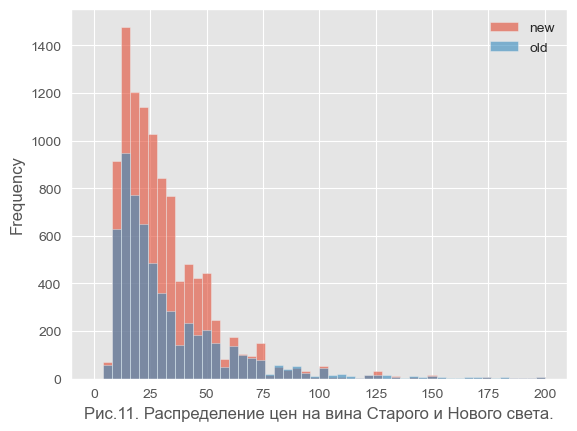

In [174]:
old_new.groupby('age')['price'].plot.hist(alpha=0.6, bins=50, range = (0, 200))
plt.xlabel('Рис.11. Распределение цен на вина Старого и Нового света.')
plt.legend(framealpha=0)

In [136]:
old_new_drop_price = old_new.dropna().reset_index(drop=True)
old_new_drop_price

,country,points,price,province,variety,winery,age
0,US,86,23.0,California,Pinot Noir,MacMurray Ranch,new
1,Italy,96,275.0,Tuscany,Red Blend,Castello dei Rampolla,old
2,France,91,40.0,Bordeaux,Bordeaux-style Red Blend,Château Bernadotte,old
3,Italy,81,15.0,Tuscany,Sangiovese,Valiano,old
4,US,83,25.0,Oregon,Pinot Noir,Deer Creek,new
...,...,...,...,...,...,...,...
16523,US,84,20.0,California,Sauvignon Blanc,Kendall-Jackson,new
16524,France,88,12.0,Southwest France,Mansois,Lionel Osmin & Cie,old
16525,US,89,50.0,California,Pinot Noir,Bouchaine,new
16526,Italy,87,20.0,Sicily & Sardinia,Zibibbo,Donnafugata,old


### Ценовая сегментация

In [138]:
for_clusters = old_new_drop_price[['price']]
for_clusters.head()

,price
0,23.0
1,275.0
2,40.0
3,15.0
4,25.0


In [139]:
# Объект, в котором будет хранится информация о последовательном слиянии кластеров
link = linkage(for_clusters, 'ward', 'euclidean')

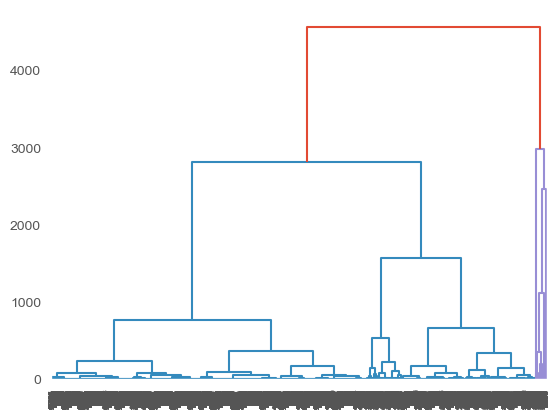

In [140]:
dn = dendrogram(link)

In [141]:
old_new_drop_price['cluster'] = fcluster(link, 2, criterion='maxclust')
old_new_drop_price.head()

,country,points,price,province,variety,winery,age,cluster
0,US,86,23.0,California,Pinot Noir,MacMurray Ranch,new,1
1,Italy,96,275.0,Tuscany,Red Blend,Castello dei Rampolla,old,2
2,France,91,40.0,Bordeaux,Bordeaux-style Red Blend,Château Bernadotte,old,1
3,Italy,81,15.0,Tuscany,Sangiovese,Valiano,old,1
4,US,83,25.0,Oregon,Pinot Noir,Deer Creek,new,1


In [142]:
old_new_drop_price.groupby('cluster')['price'].min()

cluster
1      5.0
2    115.0
Name: price, dtype: float64

* Суперпремиальный сегмент начинается от цены 115 и выше. 

### Суперпремиальный сегмент

In [143]:
pd.crosstab(old_new_drop_price['age'], old_new_drop_price['cluster']).round(2)

cluster,1,2
age,,
new,10320,136
old,5841,231


* В Старом свете премиальных вин больше. Всего в сегменте 367 наименований.

In [146]:
premium = old_new[(old_new['price'] > 114)]
premium.groupby('country').agg({'province': np.size,
                                'points': np.mean,
                                'price': np.mean
                               }).sort_values(by='province', ascending=False).round(1)

,province,points,price
country,,,
France,114,93.6,247.9
US,108,92.6,153.6
Italy,66,93.4,195.5
Spain,29,92.3,215.7
Argentina,13,93.0,147.9
Germany,12,92.5,205.3
Australia,10,92.2,206.0
Portugal,10,92.4,204.4
Chile,3,91.0,206.7


* Хорошо оцениваются премиальные вина Франции и Италии. Премиум США и Испании оценивается ниже, но все равно хорошо. Помним, что средняя оценка 88.

### Взаимосвязь оценок и цен

Text(0.5, 30.078124999999964, 'Рис.12. Диаграмма рассеивания цен и оценок вин Нового и Старого света')

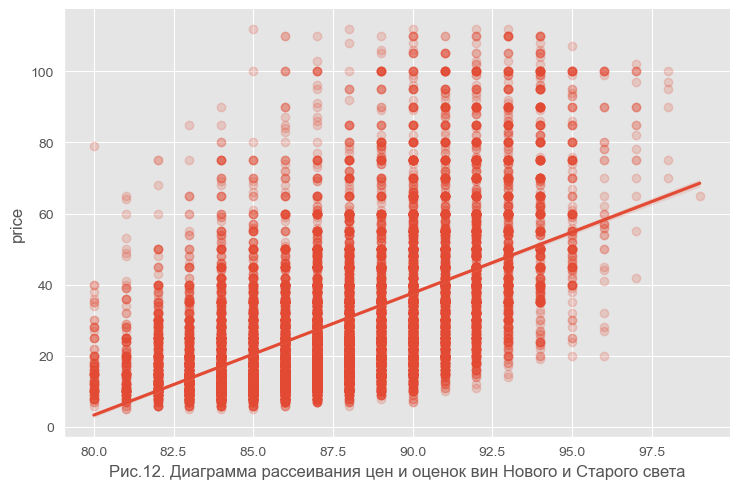

In [203]:
normal_price = old_new_drop_price[(old_new_drop_price['price'] < 115)]
sns.lmplot(x='points', y='price', data=normal_price, aspect=1.5, scatter_kws={'alpha':0.2})
plt.xlabel('Рис.12. Диаграмма рассеивания цен и оценок вин Нового и Старого света')

In [213]:
normal_price_corr = normal_price[['price', 'points']]
normal_price_corr.corr().round(2)

,price,points
price,1.00,0.56
points,0.56,1.00


* Среди вин не суперпреиум класса корреляция между оценкой вина и его ценой выше среднего.

In [200]:
# create X and y
feature_cols = ['points']
X = normal_price[feature_cols]
y = normal_price.price


# instantiate and fit
linreg = LinearRegression()
linreg.fit(X, y)

# print the coefficients
print( linreg.intercept_)
print (linreg.coef_)

-271.0289316310559
[3.42966049]


* Увеличение оценки на 1 пункт может повысить цену на 3.4.

In [208]:
print('Оценка 87: цена', linreg.predict(np.array([87]).reshape(-1,1)).round(2))
print('Оценка 89: цена', linreg.predict(np.array([89]).reshape(-1,1)).round(2))

Оценка 87: цена [27.35]
Оценка 89: цена [34.21]


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [209]:
Chardonnay = old_new[old_new['variety'] == 'Chardonnay']
Chardonnay_comp = Chardonnay.groupby('age')[['points','price']].median()
Chardonnay_comp

,points,price
age,,
new,87.0,22.0
old,89.0,40.0


In [214]:
Riesling = old_new[old_new['variety'] == 'Riesling']
Riesling_comp = Riesling.groupby('age')[['points','price']].median()
Riesling_comp

,points,price
age,,
new,87.0,16.0
old,89.0,26.0


* Даже при текущей оценке Chardonnay и Riesling произведенных в Новом свете есть потенциал для повышения цены.

#  <a name="5">5. Проверка гипотез </a>

## Гипотеза 1
* H0: Средние оценки вин Старого и Нового света одинаковые.
* H1: Средние оценки вин Старого и Нового света разные.


In [149]:
H0 = 'Оценки распрделены нормально'
H1 = 'Оценки распрделены не нормально'
k2, p = st.normaltest(old_new['points'].sample(50))
alpha = 0.01
print("p = {:g}".format(p))

if p < alpha:  # null hypothesis: x comes from a normal distribution
    print(H1)
else:
    print(H0)

p = 0.631242
Оценки распрделены нормально


In [150]:
samplingSize = 1000

old_world_wine = old_new[old_new.age == 'old'].points.sample(samplingSize).sort_values()
new_world_wine = old_new[old_new.age == 'new'].points.sample(samplingSize).sort_values()

In [151]:
test_leven, p = st.levene(old_world_wine, new_world_wine)
print('Statistics=%.3f, p-value=%.3f' % (test_leven, p))
alpha = 0.05
if p < alpha:
    print('Отклонить гипотезу о равенстве дисперсий')
else:
    print('Принять гипотезу о равенстве дисперсий')

Statistics=21.960, p-value=0.000
Отклонить гипотезу о равенстве дисперсий


In [152]:
t,p_value  = st.ttest_ind(old_world_wine,new_world_wine,  equal_var=False)

if p_value < 0.05:
    print(f'Вина Старого и Нового света оценивают неодинаково так как p value - {p_value.round(3)} < 0.05')
else:
    print(f'Вина Старого и Нового света оценивают одинаково так как p value - {p_value.round(3)} > 0.05')

Вина Старого и Нового света оценивают неодинаково так как p value - 0.0 < 0.05


## Гипотеза 2
* H0: Средние оценки вин Старого и Нового света одинаковые.
* H1: Средние оценки вин Старого света выше чем Нового.


In [154]:
t,p_value  = st.ttest_ind(old_world_wine, new_world_wine,  equal_var=False, alternative='greater')

if p_value < 0.05:
    print(f'Средняя оценка вин Старого света выше чем вин Нового света, так как p value - {p_value.round(3)} < 0.05')
else:
    print(f'Средняя оценка вин Старого и Нового света одинакова так как p value - {p_value.round(3)} > 0.05')

Средняя оценка вин Старого света выше чем вин Нового света, так как p value - 0.0 < 0.05


# <a name="6">6. Выводы</a>

В наборе данные 38 стран 7454 виноделен. Больше всего представлено вин из США - 7786.

По данным OIV (Международная организация виноградарства и виноделия) на 2017 год 57.8 % вин были произведены странами так называемого Старого света, а 28,8 % — Нового. Однако при большей номенклатуре (больше 10 тысяч наименований, почти 60%) вина Нового Света занимают такую маленькую долю в общем объеме производства (около 30%).

В среднем винодельни производят 2-3 наименования, но производители Нового света крупнее. В Старом свете винодельня в среднем проивзодит 2 наименования, в Новом - 3. Самая крупная винодельня Williams Selyem производит 51 наименование (https://www.williamsselyem.com/wine/).

Топ наименований вин Нового и Старого света различается, хотя есть и пересечения. В Старом свете лидируют Red Blend, Chardonnay, Riesling. В Новом свете больше всего вин Pinot Noir, Cabernet Savignon и Chardonnay. Самым популярный сорт винограда Pinot Noir, есть в портфеле 887 производителей производителей.

Количество производителей сопоставимо, но в Новом свете меньше разнообразие сортов винограда, больше портфель,, а также топ наименования встречаются у большего количества производителе и, следовательно, их портфели более однородный. Например вариантов Chardonnay в США производят в 3 раза больше, чем в старой Европе. То есть, выходя на рынок, производитель в США предпочитает вкладывать в уже раскрученное наименование, гарантируя выручку.

В целом средняя оценка вин Старого света выше чем Нового, хотя средние цены Нового света выше. Одинаковые сорта вин Нового света оцениваются также или хуже, чем старого. При одинаковых оценках вина Нового светаЕсть достаточно значительная кдороже.

Корреляция между ценой и. Коэффициент корреляции: 0.56.начительная.

Для Нового света может быть несколько , которые учитывают тенденцию производителей выпускать уже известные на рынке сорта.утей развития. Фокусировать развитие на сортах среднего и верхнего ценового семгмента, которые оцениваются таже хорошо, как европейс вводить в ассортименткие, например, Red Blend, который в Новом свете выпускает сравнительно небольшое количество виноделен, оно оценивается так же хорошо как европейское, а стоимость даже выше. Или же заниматься улучшением качества популярных вин таких как Chardonnay и Riesling, чтобы улучшить оценку и поднять цену в , хотя цены на эти вина можно поднимать на 20% даже при текущем уровне рейтинга.реднем на 60%.

Для Старого света привлекательным может быть развитие премиального сегмента, более дорогих , локальных, особенных винсортов винограда. Рынок в целом восприминаем Старый свет как более элитный и
Также есть возможность для повышения цен на Bordeaux-style Red Blend, который имеет хорошие оценки, но почти в два раза дешевше такого же вина производства Нового света. оценивает выше.

**<center>Список литературы</center>**


**Нормативные правовые акты:**
1.	Профессиональный стандарт «Специалист по большим данным» утверждён приказом Министерства труда и социальной защиты Российской Федерации от 6 июля 2020 г. № 405н.

**Учебники и учебные пособия:**
1.	Андерсон. К., Аналитическая культура: от сбора данных до бизнес-результатов. - Москва : Манн, Иванов и Фербер, 2017.
2.	Нисчал Н., Python – это просто. Пошаговое руководство по программированию и анализу данных. — СПб.: БХВ-Петербург, 2021.
3.	Мэтиз Э., Изучаем Python. Программирование игр, визуализация данных, веб-приложения. — СПб.: Питер, 2021.
4.	Пасхавер Б., Pandas в действии. — СПб.: Питер, 2023.
5.	Плас Дж. Вандер., Python для сложных задач: наука о данных — СПб.: Питер, 2024.
6.	Уилке К., Основы визуализации данных. Пособие по эффективной и убедительной подаче информации.— М.: Эксмо, 2024.

**Электронные ресурсы:**
1.	PEP 8 – руководство по стилю для кода Python [Электронный ресурс]: URL: https://peps.python.org/pep-0008/ ((дата обращения: 05.04.2024).
2.	Сайт Python Academy [Электронный ресурс]: URL: https://www.python-academy.com/ (дата обращения: 05.04.2024).

